<a href="https://colab.research.google.com/github/noorh4/customer-churn-prediction/blob/main/telco_customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

**EDA**

In [ ]:
print("\nHead(5):")
df.head()


Head(5):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
for col in df.columns:
    if col.lower() != "customerid":
        unique_vals = df[col].unique()
        print(f"--- {col} ---")
        print(unique_vals)
        print(f"Count: {len(unique_vals)}")
        print("-"*40)

--- gender ---
['Female' 'Male']
Count: 2
----------------------------------------
--- SeniorCitizen ---
[0 1]
Count: 2
----------------------------------------
--- Partner ---
['Yes' 'No']
Count: 2
----------------------------------------
--- Dependents ---
['No' 'Yes']
Count: 2
----------------------------------------
--- tenure ---
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
Count: 73
----------------------------------------
--- PhoneService ---
['No' 'Yes']
Count: 2
----------------------------------------
--- MultipleLines ---
['No phone service' 'No' 'Yes']
Count: 3
----------------------------------------
--- InternetService ---
['DSL' 'Fiber optic' 'No']
Count: 3
----------------------------------------
--- OnlineSecurity ---
['No' 'Yes' 'No internet service']
Count: 3
--------------------------------

In [ ]:
print("Shape:", df.shape)

print("\nDtypes:")
print(df.dtypes)

Shape: (7043, 21)

Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
# Missing values & duplicates
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows count:", df.duplicated().sum())


Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows count: 0


In [ ]:
# Empty Cells in all columns
for col in df.columns:
    empty_mask = df[col].astype(str).str.strip() == ""
    empty_count = empty_mask.sum()
    if empty_count > 0:
        print(f"Column: {col}  --> {empty_count} empty values")

Column: TotalCharges  --> 11 empty values


In [ ]:
mask = df['TotalCharges'].astype(str).str.strip() == ""

df_missing_total = df.loc[mask, ['customerID', 'tenure', 'TotalCharges']]

df_missing_total

,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


In [ ]:
#Identify numeric/categorical columns
numeric_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
categorical_cols = [c for c in df.columns if c not in numeric_cols]

print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)



Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [ ]:
#Target balance
target_col = None
for c in df.columns:
    if str(c).strip().lower() == "churn":
        target_col = c
        break

if target_col is not None:
    print(f"\nClass balance for '{target_col}':")
    print(df[target_col].value_counts(dropna=False))
    print("\nClass ratio (%):")
    print((df[target_col].value_counts(normalize=True)*100).round(2))
else:
    print("\n No 'Churn' column found (case-insensitive).")


Class balance for 'Churn':
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class ratio (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [ ]:
# Descriptive stats (Numeric only)
if numeric_cols:
    print("\nDescriptive statistics (numeric):")
    print(df[numeric_cols].describe().T)



Descriptive statistics (numeric):
                 count       mean        std    min   25%    50%    75%  \
SeniorCitizen   7043.0   0.162147   0.368612   0.00   0.0   0.00   0.00   
tenure          7043.0  32.371149  24.559481   0.00   9.0  29.00  55.00   
MonthlyCharges  7043.0  64.761692  30.090047  18.25  35.5  70.35  89.85   

                   max  
SeniorCitizen     1.00  
tenure           72.00  
MonthlyCharges  118.75  


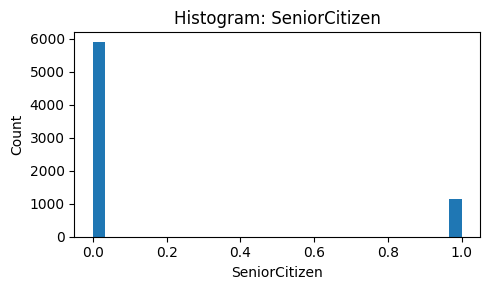

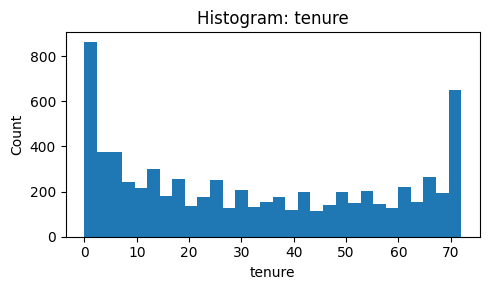

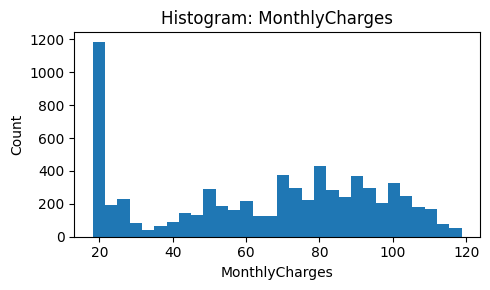

In [ ]:
# Quick histograms for numeric columns
for col in numeric_cols[:6]:
    plt.figure(figsize=(5,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col); plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

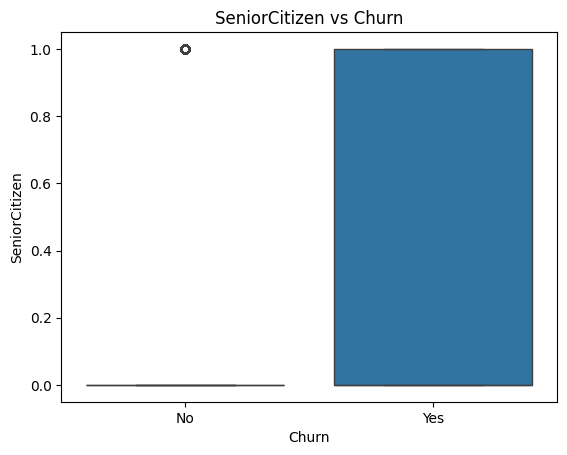

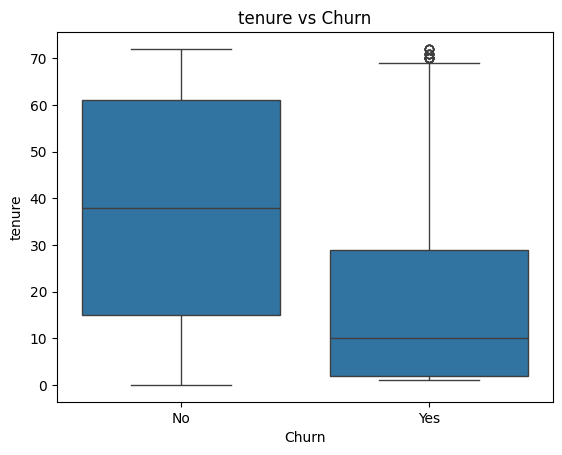

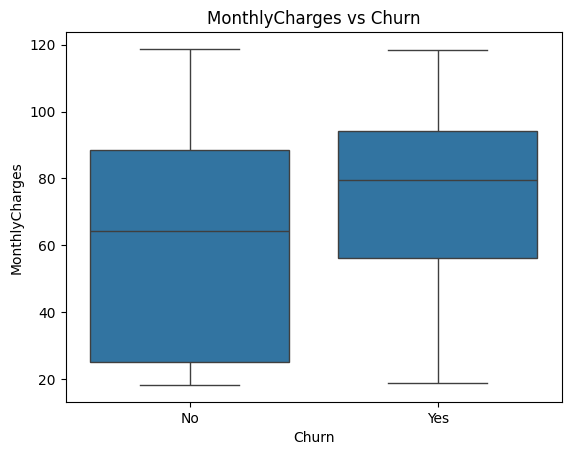

In [ ]:
# Boxplot for each numeric feature against the Churn variable
import seaborn as sns

for col in numeric_cols:
    sns.boxplot(x=df['Churn'], y=df[col])
    plt.title(f"{col} vs Churn")
    plt.show()


Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling']


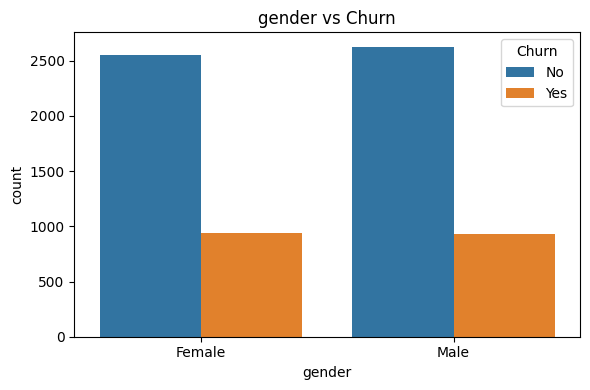

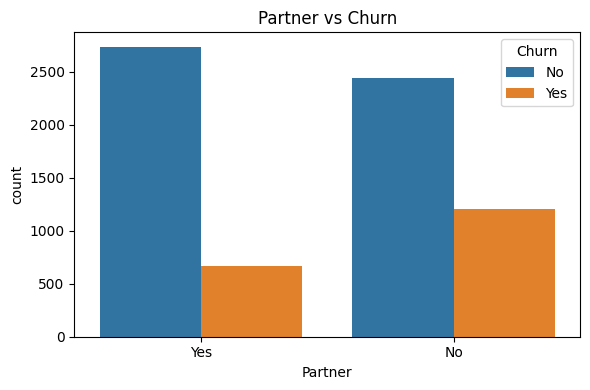

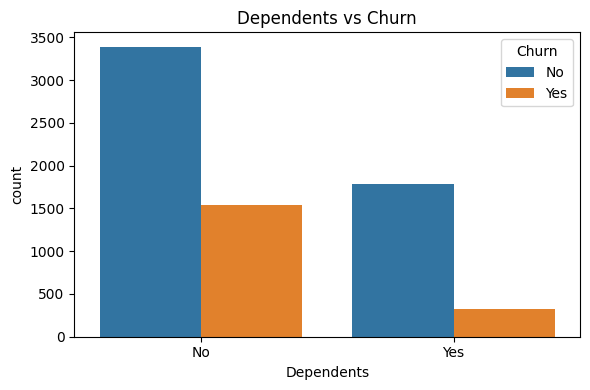

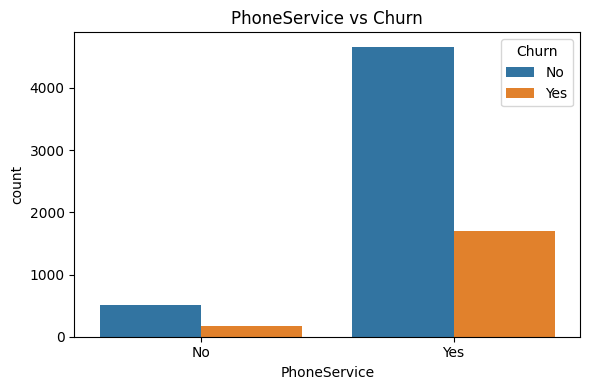

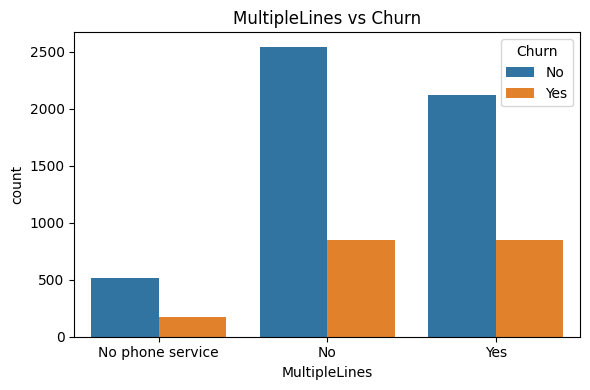

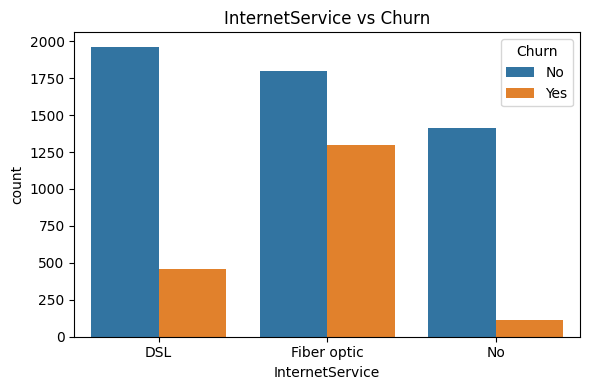

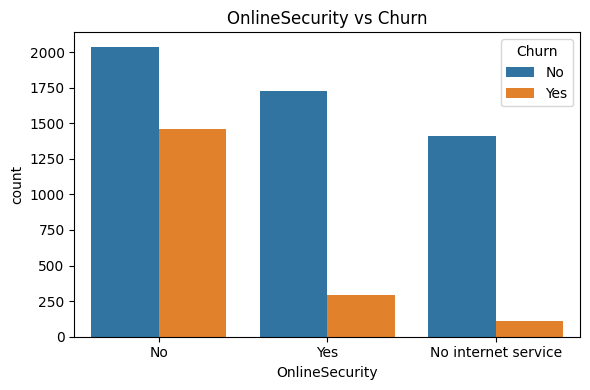

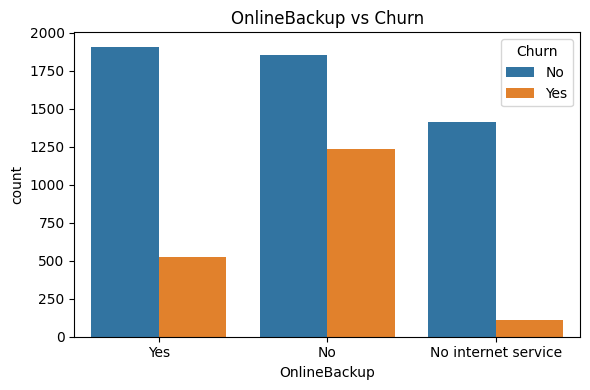

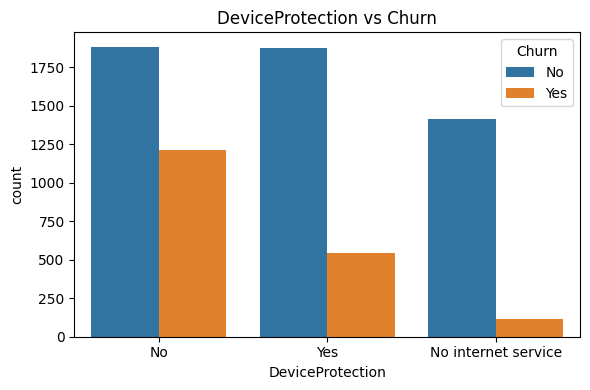

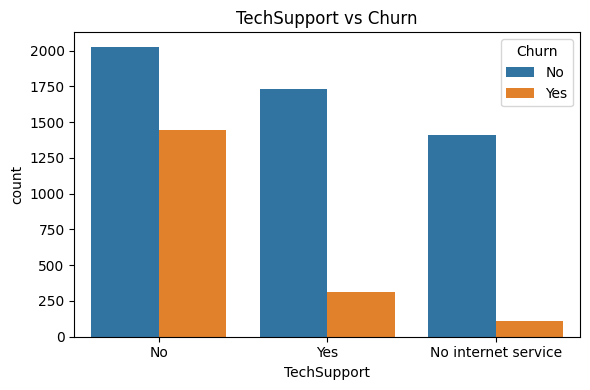

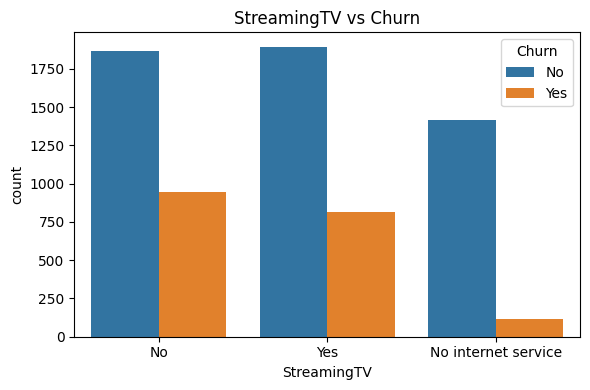

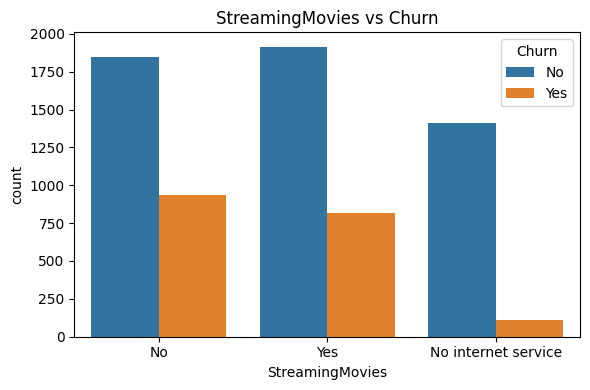

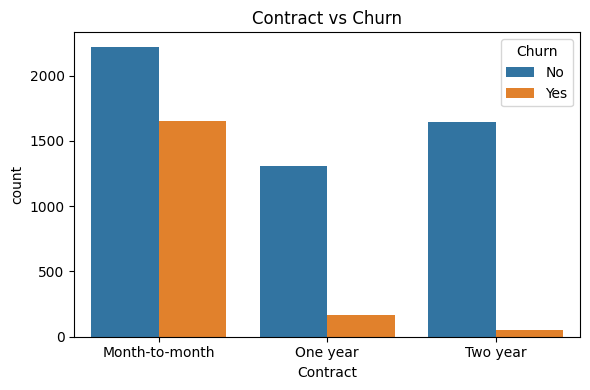

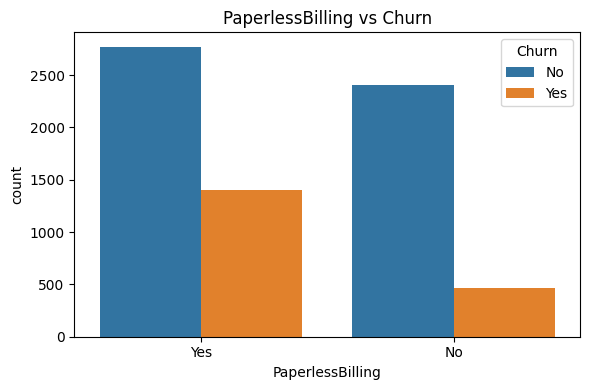

In [ ]:
# Categorical vs Churn

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Identify categorical columns
categorical_cols = [c for c in df.columns if not np.issubdtype(df[c].dtype, np.number)]

# Remove target + customerID + PaymentMethod + TotalCharges
categorical_cols = [
    c for c in categorical_cols
    if c.lower() not in ['churn', 'customerid', 'paymentmethod', 'totalcharges']
]

print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], hue=df['Churn'])
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


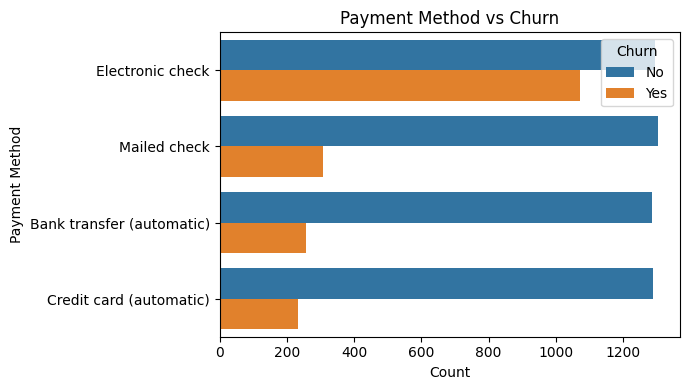

In [ ]:
# PaymentMethod vs Churn (Horizontal Bar Plot)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.countplot(
    y=df["PaymentMethod"],
    hue=df["Churn"]
)

plt.title("Payment Method vs Churn")
plt.xlabel("Count")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Count')

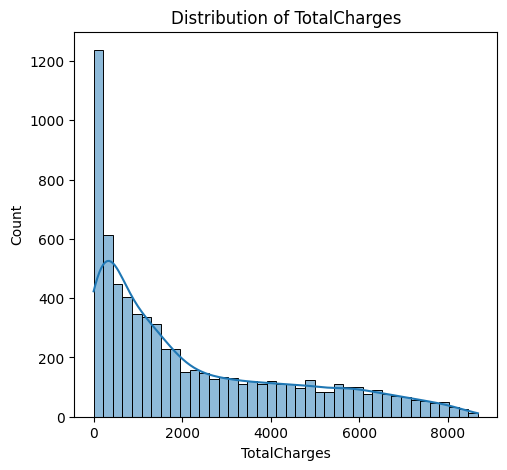

In [ ]:
#
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df['TotalCharges'], bins=40, kde=True)
plt.title("Distribution of TotalCharges")
plt.xlabel("TotalCharges")
plt.ylabel("Count")


#Long-term customers naturally have much higher total charges compared to new customer

**Data preprocessing**

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

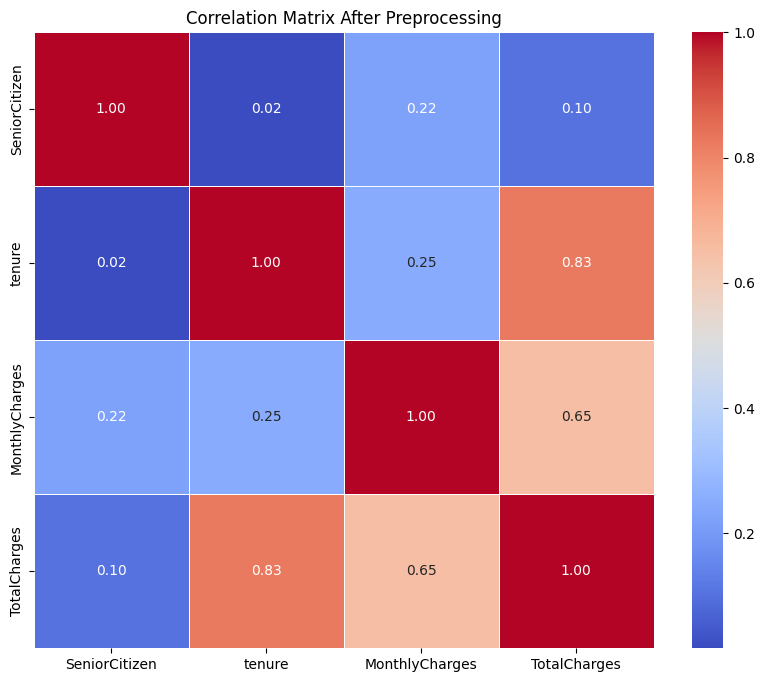

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_after = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_after, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix After Preprocessing")
plt.show()


In [ ]:
# Encoding

#  Encode Yes/No columns
yes_no_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for c in yes_no_cols:
    if c in df.columns:
        df[c] = df[c].map({'Yes':1, 'No':0}).astype('int64')

#  Internet-related columns (replace "No internet service" with "No")
internet_cols = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]
for c in internet_cols:
    if c in df.columns:
        df[c] = df[c].replace({'No internet service':'No'}).map({'Yes':1,'No':0}).astype('int64')

# MultipleLines (replace "No phone service")
if 'MultipleLines' in df.columns:
    df['MultipleLines'] = df['MultipleLines'].replace({'No phone service':'No'}).map({'Yes':1,'No':0}).astype('int64')

#  Gender
if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'Female':0,'Male':1}).astype('int64')

#  Contract (Ordinal: logical order)
if 'Contract' in df.columns:
    df['Contract'] = df['Contract'].map({'Month-to-month':0, 'One year':1, 'Two year':2}).astype('int64')

#  InternetService & PaymentMethod (limited one-hot, drop first)
small_one_hot = ['InternetService','PaymentMethod']
for c in small_one_hot:
    if c in df.columns:
        dummies = pd.get_dummies(df[c], prefix=c, drop_first=True)
        df = pd.concat([df.drop(columns=[c]), dummies], axis=1)

print(" Encoding done — replaced original columns, no explosion")
print(" Shape now:", df.shape)
df.head()

 Encoding done — replaced original columns, no explosion
 Shape now: (7043, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,0,0,1,...,0,1,29.85,29.85,0,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,1,0,...,1,0,56.95,1889.50,0,False,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,0,1,53.85,108.15,1,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,1,0,...,1,0,42.30,1840.75,0,False,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,0,0,0,...,0,1,70.70,151.65,1,True,False,False,True,False


In [ ]:
# convert any True/False columns to 0/1
df = df.replace({True:1, False:0})

/tmp/ipython-input-3268633535.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True:1, False:0})


**Feature Engineering**

In [ ]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [ ]:
'''
 أعمدة العميل الأساسية
customerID, gender, SeniorCitizen, Partner, Dependents,tenure, PhoneService, MultipleLines, PaperlessBilling, Contract

 أعمدة الأمان/الإنترنت
OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

 الفواتير
MonthlyCharges, TotalCharges

 الهدف
Churn (0/1)

 للإنترنت
InternetService_Fiber optic, InternetService_No

 للدفع
PaymentMethod_Credit card (automatic), PaymentMethod_Electronic check, PaymentMethod_Mailed check

'''

In [ ]:
# 1) HasFamily
df['HasFamily'] = df['Partner'] + df['Dependents']

# 2) TenureYears
df['TenureYears'] = df['tenure'] / 12

# 3) AvgMonthlyCharge
df['AvgMonthlyCharge'] = df['TotalCharges'] / df['tenure']
df['AvgMonthlyCharge'] = df['AvgMonthlyCharge'].replace([np.inf, -np.inf], 0).fillna(0)

# 4) IsNewCustomer
df['IsNewCustomer'] = (df['tenure'] < 6).astype(int)

print(" Feature Engineering Done!")
df.head()


 Feature Engineering Done!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,HasFamily,TenureYears,AvgMonthlyCharge,IsNewCustomer
0,7590-VHVEG,0,0,1,0,1,0,0,0,1,...,0,0,0,0,1,0,1,0.083333,29.850000,1
1,5575-GNVDE,1,0,0,0,34,1,0,1,0,...,0,0,0,0,0,1,0,2.833333,55.573529,0
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,...,1,0,0,0,0,1,0,0.166667,54.075000,1
3,7795-CFOCW,1,0,0,0,45,0,0,1,0,...,0,0,0,0,0,0,0,3.750000,40.905556,0
4,9237-HQITU,0,0,0,0,2,1,0,0,0,...,1,1,0,0,1,0,0,0.166667,75.825000,1


In [ ]:
'''
HasFamily	Partner + Dependents	العميل اللي عنده عائلة غالبًا أثبت ولاء أكثر
AvgMonthlyCharge: TotalCharges / tenure	نعرف متوسط إنفاقه الشهري الحقيقي
TenureYears	   : tenure / 12	تحويل مدة الاشتراك لسنوات (أوضح)
IsNewCustomer	   : tenure < 6	العملاء الجدد غالبًا churn عالي
'''

**Train/Test Split.**

In [ ]:
from sklearn.model_selection import train_test_split

# (y)
y = df['Churn']

X = df.drop(columns=['Churn','customerID'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(" Split Done!")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


 Split Done!
X_train: (5634, 26)
X_test : (1409, 26)
y_train: (5634,)
y_test : (1409,)


**Train baseline LogisticRegression model**

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, solver='lbfgs', n_jobs=-1)
logreg.fit(X_train, y_train)

print(" Model training completed.")


 Model training completed.


 baseline LogisticRegression model Evaluation Results:
Accuracy : 0.806
Precision: 0.666
Recall   : 0.537  (Important for churn)
F1-score : 0.595
AUC-ROC  : 0.848

 Classification Report:
              precision    recall  f1-score   support

           0      0.844     0.902     0.872      1035
           1      0.666     0.537     0.595       374

    accuracy                          0.806      1409
   macro avg      0.755     0.720     0.733      1409
weighted avg      0.796     0.806     0.798      1409



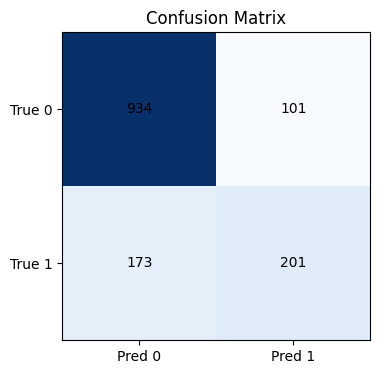

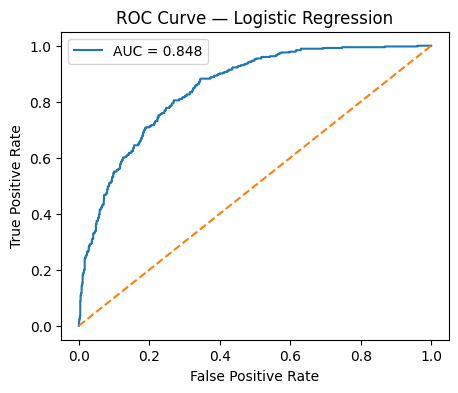

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve

#  Predictions
y_pred  = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

#  Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print(" baseline LogisticRegression model Evaluation Results:")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}  (Important for churn)")
print(f"F1-score : {f1:.3f}")
print(f"AUC-ROC  : {auc:.3f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xticks([0,1], ['Pred 0','Pred 1'])
plt.yticks([0,1], ['True 0','True 1'])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.show()

#  ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()


**Address imbalance + Balanced Logistic Regression**:

In [ ]:
from sklearn.linear_model import LogisticRegression

#  Train logistic regression with class weighting to handle imbalance
logreg_bal = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    n_jobs=-1
)
logreg_bal.fit(X_train, y_train)

print(" Balanced model training completed.")


 Balanced model training completed.


 Balanced Logistic Regression Results:
Accuracy : 0.742
Precision: 0.508
Recall   : 0.805
F1-score : 0.623
AUC-ROC  : 0.848

 Classification Report:
              precision    recall  f1-score   support

           0      0.911     0.719     0.803      1035
           1      0.508     0.805     0.623       374

    accuracy                          0.742      1409
   macro avg      0.710     0.762     0.713      1409
weighted avg      0.804     0.742     0.756      1409



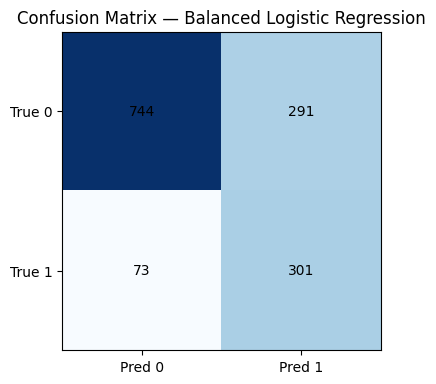

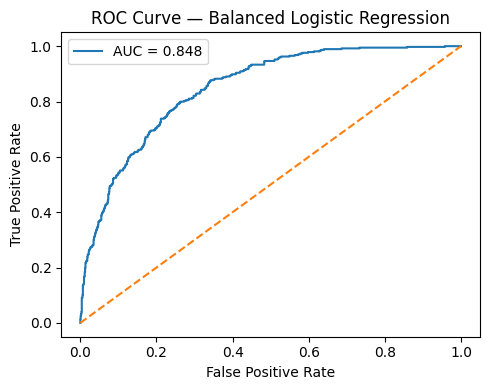

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred_bal  = logreg_bal.predict(X_test)
y_proba_bal = logreg_bal.predict_proba(X_test)[:, 1]

#  Metrics
acc  = accuracy_score(y_test, y_pred_bal)
prec = precision_score(y_test, y_pred_bal)
rec  = recall_score(y_test, y_pred_bal)   # مهم لفئة churn=1
f1   = f1_score(y_test, y_pred_bal)
auc  = roc_auc_score(y_test, y_proba_bal)

print(" Balanced Logistic Regression Results:")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"AUC-ROC  : {auc:.3f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_bal, digits=3))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred_bal)
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix — Balanced Logistic Regression")
plt.xticks([0,1], ['Pred 0','Pred 1'])
plt.yticks([0,1], ['True 0','True 1'])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.show()

#  ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_bal)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Balanced Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
'''
Accuracy        	0.806   	0.742   	طبيعي تقل شوي
Precision	        0.666    	0.508
Recall (Churn)	  0.537	    0.805	   تحسن كبير جدًا
F1	              0.595	    0.623	    تحسن
AUC	              0.848	    0.848	    ثابت وممتاز

'''

**Trying another model {balanced Random Forest}**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Model
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)

print(" Random Forest training completed.")

 Random Forest training completed.


 Random Forest Evaluation:
Accuracy : 0.790
Precision: 0.638
Recall   : 0.481
F1-score : 0.549
AUC-ROC  : 0.831

 Classification Report:
              precision    recall  f1-score   support

           0      0.828     0.901     0.863      1035
           1      0.638     0.481     0.549       374

    accuracy                          0.790      1409
   macro avg      0.733     0.691     0.706      1409
weighted avg      0.778     0.790     0.780      1409



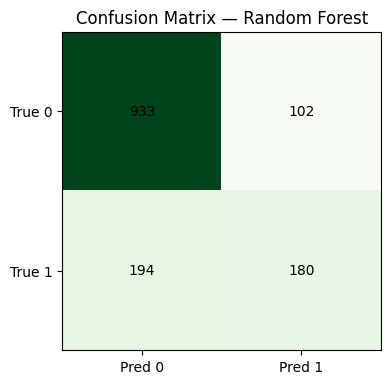

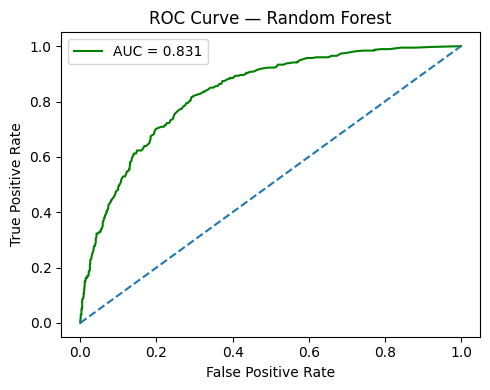

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve

#  Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

#  Metrics
acc  = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf)
rec  = recall_score(y_test, y_pred_rf)
f1   = f1_score(y_test, y_pred_rf)
auc  = roc_auc_score(y_test, y_proba_rf)

print(" Random Forest Evaluation:")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"AUC-ROC  : {auc:.3f}\n")

print(" Classification Report:")
print(classification_report(y_test, y_pred_rf, digits=3))

#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Greens')
plt.title("Confusion Matrix — Random Forest")
plt.xticks([0,1], ['Pred 0','Pred 1'])
plt.yticks([0,1], ['True 0','True 1'])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.show()

#  ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='green')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()


**Trying another model {balanced XGBoost}**

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

# XGBoost Model (optimized for imbalance)
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),  # imbalance handling
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

print("XGBoost training completed.")


XGBoost training completed.


 XGBoost Evaluation:
Accuracy : 0.762
Precision: 0.538
Recall   : 0.719
F1-score : 0.616
AUC-ROC  : 0.835

 Classification Report:
              precision    recall  f1-score   support

           0      0.884     0.777     0.827      1035
           1      0.538     0.719     0.616       374

    accuracy                          0.762      1409
   macro avg      0.711     0.748     0.721      1409
weighted avg      0.793     0.762     0.771      1409



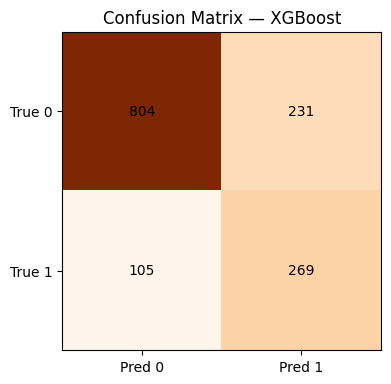

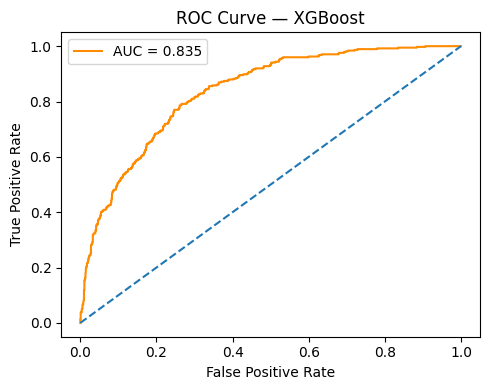

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

# Metrics
acc  = accuracy_score(y_test, y_pred_xgb)
prec = precision_score(y_test, y_pred_xgb)
rec  = recall_score(y_test, y_pred_xgb)
f1   = f1_score(y_test, y_pred_xgb)
auc  = roc_auc_score(y_test, y_proba_xgb)

print(" XGBoost Evaluation:")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"AUC-ROC  : {auc:.3f}\n")

print(" Classification Report:")
print(classification_report(y_test, y_pred_xgb, digits=3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Oranges')
plt.title("Confusion Matrix — XGBoost")
plt.xticks([0,1], ['Pred 0','Pred 1'])
plt.yticks([0,1], ['True 0','True 1'])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.show()

#  ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='darkorange')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost")
plt.legend()
plt.tight_layout()
plt.show()


**Feature Importance**

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logreg_bal.coef_[0]
})

# Decending order depending on importance
feature_importance['AbsCoefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='AbsCoefficient', ascending=False)

feature_importance


,Feature,Coefficient,AbsCoefficient
25,IsNewCustomer,0.810753,0.810753
13,Contract,-0.760819,0.760819
5,PhoneService,-0.757642,0.757642
18,InternetService_No,-0.478466,0.478466
17,InternetService_Fiber optic,0.477316,0.477316
7,OnlineSecurity,-0.444250,0.444250
10,TechSupport,-0.382309,0.382309
20,PaymentMethod_Electronic check,0.347962,0.347962
14,PaperlessBilling,0.347114,0.347114
8,OnlineBackup,-0.220692,0.220692


In [ ]:
'''
high importance:
 IsNewCustomer              العملاء الجدد أكثر احتمال للانسحاب
 Contract                  العقود الطويلة تقلل احتمالية الانسحاب
 PhoneService               وجود هاتف ثابت يقلل الانسحاب (غير متوقع قليلًا)
 InternetService_Fiber optic    ألياف = احتمال أعلى للانسحاب (السعر غالبًا)
 OnlineSecurity             وجود حماية يقلل الانسحاب
 TechSupport                الدعم الفني يقلل الانسحاب
 Electronic check           الدفع الإلكتروني مرتبط بزيادة الانسحاب
 PaperlessBilling           الفواتير الإلكترونية مرتبطة بزيادة الانسحاب


less importance :
 TenureYears, MonthlyCharges, TotalCharges , gender, PaymentMethod_Mailed check , HasFamily, DeviceProtection

'''


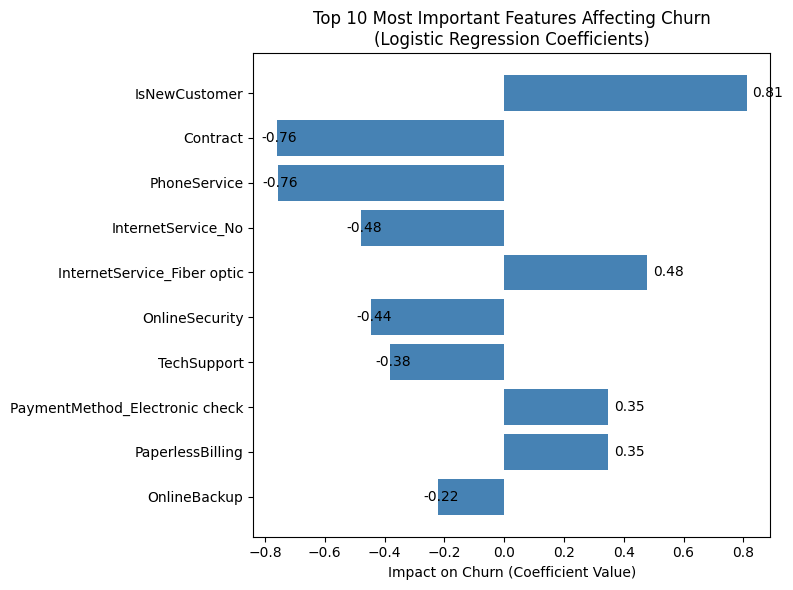

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
bars = plt.barh(top_features['Feature'], top_features['Coefficient'], color='steelblue')
plt.title("Top 10 Most Important Features Affecting Churn\n(Logistic Regression Coefficients)")
plt.xlabel("Impact on Churn (Coefficient Value)")
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + (0.02 if width > 0 else -0.05), bar.get_y() + bar.get_height()/2,
             f"{width:.2f}", va='center')

plt.tight_layout()
plt.show()

**Feature Selection**

In [ ]:
#  Copy original df to new dataset for feature selection
selected_df = df.copy()

#  Features to drop (based on low importance + redundancy)
features_to_drop = [
    'MonthlyCharges',
    'TotalCharges',
    'TenureYears',
    'gender',
    'DeviceProtection',
    'HasFamily'
]

selected_df = selected_df.drop(columns=features_to_drop)

print(" Selected Features Count:", selected_df.shape[1])
print(" Final Selected Features:")
print(selected_df.columns.tolist())


 Selected Features Count: 22
 Final Selected Features:
['customerID', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'AvgMonthlyCharge', 'IsNewCustomer']


In [ ]:
selected_df.to_csv("telco_selected_features.csv", index=False)

In [ ]:
from sklearn.model_selection import train_test_split

#  Features / Target
X2 = selected_df.drop(columns=['Churn', 'customerID'])
y2 = selected_df['Churn']

#  Train-Test Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print(" New Split Done")
print("X2_train:", X2_train.shape)
print("X2_test :", X2_test.shape)


 New Split Done
X2_train: (5634, 20)
X2_test : (1409, 20)


**Retrain + Retest TO enure that model not lose any important into**

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg2 = LogisticRegression(max_iter=1000, solver='lbfgs', class_weight='balanced')
logreg2.fit(X2_train, y2_train)

print(" Logistic (balanced) retrained on selected features")


 Logistic (balanced) retrained on selected features


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

y2_pred = logreg2.predict(X2_test)
y2_proba = logreg2.predict_proba(X2_test)[:,1]

print(" Evaluation — Logistic Selected")

print("Accuracy :", accuracy_score(y2_test, y2_pred))
print("Precision:", precision_score(y2_test, y2_pred))
print("Recall   :", recall_score(y2_test, y2_pred))
print("F1       :", f1_score(y2_test, y2_pred))
print("AUC      :", roc_auc_score(y2_test, y2_proba))

print("\nReport:\n", classification_report(y2_test, y2_pred, digits=3))


 Evaluation — Logistic Selected
Accuracy : 0.7452093683463449
Precision: 0.5127768313458262
Recall   : 0.8048128342245989
F1       : 0.6264308012486993
AUC      : 0.8477382520860781

Report:
               precision    recall  f1-score   support

           0      0.911     0.724     0.807      1035
           1      0.513     0.805     0.626       374

    accuracy                          0.745      1409
   macro avg      0.712     0.764     0.717      1409
weighted avg      0.805     0.745     0.759      1409



In [ ]:
#  Train XGBoost on selected features
try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost
    from xgboost import XGBClassifier

pos_weight = (len(y2_train) - y2_train.sum()) / y2_train.sum()

xgb2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,   # لمعالجة عدم التوازن
    random_state=42,
    eval_metric='logloss'
)

xgb2.fit(X2_train, y2_train)
print(" XGBoost (selected features) training completed.")


 XGBoost (selected features) training completed.


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt

#  Predictions
y2_pred_xgb  = xgb2.predict(X2_test)
y2_proba_xgb = xgb2.predict_proba(X2_test)[:, 1]

#  Metrics
acc  = accuracy_score(y2_test, y2_pred_xgb)
prec = precision_score(y2_test, y2_pred_xgb)
rec  = recall_score(y2_test, y2_pred_xgb)
f1   = f1_score(y2_test, y2_pred_xgb)
auc  = roc_auc_score(y2_test, y2_proba_xgb)

print(" XGBoost (Selected Features) — Evaluation")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"AUC-ROC  : {auc:.3f}\n")

print(" Classification Report:")
print(classification_report(y2_test, y2_pred_xgb, digits=3))

 XGBoost (Selected Features) — Evaluation
Accuracy : 0.760
Precision: 0.535
Recall   : 0.727
F1-score : 0.617
AUC-ROC  : 0.833

 Classification Report:
              precision    recall  f1-score   support

           0      0.887     0.772     0.825      1035
           1      0.535     0.727     0.617       374

    accuracy                          0.760      1409
   macro avg      0.711     0.750     0.721      1409
weighted avg      0.794     0.760     0.770      1409



**New customer**

In [ ]:
#  Compare Model Performance for IsNewCustomer
#  at 6, 12, and 18 months using XGBoost

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import xgboost as xgb

def eval_is_new(th_months):
    df_tmp = selected_df.copy()

    df_tmp["IsNewCustomer"] = (df_tmp["tenure"] < th_months).astype(int)

    # Features / Target
    X = df_tmp.drop(columns=["Churn", "customerID"])
    y = df_tmp["Churn"].replace({"No": 0, "Yes": 1})

    # Train-Test Split 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = xgb.XGBClassifier(
        n_estimators=50,
        learning_rate=0.05,
        max_depth=5,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    model.fit(X_train, y_train)

    # props+ threshold = 0.45
    TH = 0.45
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= TH).astype(int)

    return {
        "IsNewCustomer < (months)": th_months,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1": round(f1_score(y_test, y_pred), 3),
        "AUC": round(roc_auc_score(y_test, y_prob), 3),
    }

thresholds = [6, 12, 18]
results = [eval_is_new(t) for t in thresholds]

results_df = pd.DataFrame(results)
print("\n Model Performance for Different IsNewCustomer Definitions:\n")
print(results_df.to_string(index=False))


 Model Performance for Different IsNewCustomer Definitions:

 IsNewCustomer < (months)  Accuracy  Precision  Recall    F1   AUC
                        6     0.798      0.633   0.572 0.601 0.847
                       12     0.799      0.637   0.564 0.599 0.848
                       18     0.805      0.649   0.578 0.611 0.849


In [ ]:
selected_df_18 = selected_df.copy()
selected_df_18["IsNewCustomer"] = selected_df_18["tenure"] < 18

In [ ]:
selected_df_18.to_csv("telco_selected_features_18months.csv", index=False)

In [ ]:
import pandas as pd
df_final = pd.read_csv("/content/telco_selected_features_18months.csv")

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd


# (y2)
y2 = selected_df_18["Churn"]

# (X2)
X2 = selected_df_18.drop(columns=["Churn", "customerID"])

#Final Train/Test Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("Final Split Done (selected_18)")
print("X2_train:", X2_train.shape)
print("X2_test :", X2_test.shape)
print("y2_train:", y2_train.shape)
print("y2_test :", y2_test.shape)

print("Same columns order?", list(X2_train.columns) == list(X2_test.columns))


Final Split Done (selected_18)
X2_train: (5634, 20)
X2_test : (1409, 20)
y2_train: (5634,)
y2_test : (1409,)
Same columns order? True


**Threshold Models tuning**

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Train Logistic on selected_18
logreg2 = LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced", n_jobs=-1)
logreg2.fit(X2_train, y2_train)

# probabilities (THIS is y2_proba your cell needs)
y2_proba = logreg2.predict_proba(X2_test)[:, 1]

thresholds = np.arange(0.30, 0.61, 0.05)
rows = []

for th in thresholds:
    y_hat = (y2_proba >= th).astype(int)
    rows.append([
        th,
        accuracy_score(y2_test, y_hat),
        precision_score(y2_test, y_hat, zero_division=0),
        recall_score(y2_test, y_hat),
        f1_score(y2_test, y_hat),
    ])

df_lr_th = pd.DataFrame(rows, columns=["Threshold", "Accuracy", "Precision", "Recall", "F1"])
print("Threshold Performance Table:\n")
print(df_lr_th)

cands = df_lr_th[df_lr_th["Recall"] >= 0.70]
best_th = (cands.loc[cands["F1"].idxmax(), "Threshold"]
           if not cands.empty
           else df_lr_th.loc[df_lr_th["F1"].idxmax(), "Threshold"])

print(f"\nChosen Threshold: {best_th:.2f}")


Threshold Performance Table:

   Threshold  Accuracy  Precision    Recall        F1
0       0.30  0.651526   0.427509  0.922460  0.584251
1       0.35  0.682754   0.451527  0.909091  0.603372
2       0.40  0.713982   0.478645  0.868984  0.617284
3       0.45  0.724627   0.488818  0.818182  0.612000
4       0.50  0.736693   0.502600  0.775401  0.609884
5       0.55  0.760114   0.534483  0.745989  0.622768
6       0.60  0.771469   0.553942  0.713904  0.623832

Chosen Threshold: 0.60


Logistic Regression (selected_18) @ TH=0.6
Accuracy : 0.7714691270404542
Precision: 0.553941908713693
Recall   : 0.713903743315508
F1-score : 0.6238317757009346

Classification Report:

              precision    recall  f1-score   support

           0      0.885     0.792     0.836      1035
           1      0.554     0.714     0.624       374

    accuracy                          0.771      1409
   macro avg      0.719     0.753     0.730      1409
weighted avg      0.797     0.771     0.780      1409



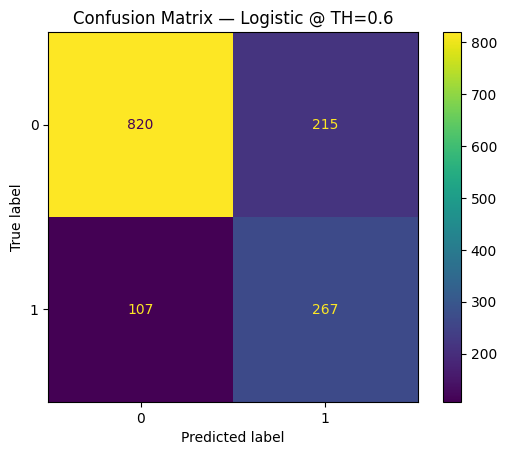

In [ ]:
#LR 0.60
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


BEST_TH = 0.60

y2_pred_lr = (y2_proba >= BEST_TH).astype(int)

print(f"Logistic Regression (selected_18) @ TH={BEST_TH}")
print("Accuracy :", accuracy_score(y2_test, y2_pred_lr))
print("Precision:", precision_score(y2_test, y2_pred_lr, zero_division=0))
print("Recall   :", recall_score(y2_test, y2_pred_lr))
print("F1-score :", f1_score(y2_test, y2_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y2_test, y2_pred_lr, digits=3))

# Confusion Matrix
cm = confusion_matrix(y2_test, y2_pred_lr)
ConfusionMatrixDisplay(cm).plot(values_format='d')
plt.title(f"Confusion Matrix — Logistic @ TH={BEST_TH}")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

# probabilities from XGBoost (selected_18)
probs = xgb2.predict_proba(X2_test)[:, 1]

results = []

for th in thresholds:
    preds = (probs >= th).astype(int)

    acc  = accuracy_score(y2_test, preds)
    prec = precision_score(y2_test, preds, zero_division=0)
    rec  = recall_score(y2_test, preds)
    f1   = f1_score(y2_test, preds)

    results.append([th, acc, prec, rec, f1])

df_threshold = pd.DataFrame(
    results,
    columns=["Threshold", "Accuracy", "Precision", "Recall", "F1"]
)

print("XGBoost — Threshold Tuning (selected_18):\n")
display(df_threshold)

#the best teade off & less false positive  0.50

XGBoost — Threshold Tuning (selected_18):



,Threshold,Accuracy,Precision,Recall,F1
0,0.50,0.755855,0.528626,0.740642,0.616927
1,0.45,0.745209,0.513321,0.772727,0.616862
2,0.40,0.727466,0.491749,0.796791,0.608163
3,0.35,0.718950,0.483077,0.839572,0.613281
4,0.30,0.703336,0.468208,0.866310,0.607880


In [ ]:
# Train + Evaluate XGBoost (selected_18)

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

pos_weight = (len(y2_train) - y2_train.sum()) / y2_train.sum()

xgb2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric="logloss"
)
xgb2.fit(X2_train, y2_train)

# (threshold = 0.50)
y_prob = xgb2.predict_proba(X2_test)[:, 1]
y_pred = (y_prob >= 0.50).astype(int)

print("XGBoost (selected_18) Evaluation @ TH=0.50")
print("Accuracy :", accuracy_score(y2_test, y_pred))
print("Precision:", precision_score(y2_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y2_test, y_pred))
print("F1       :", f1_score(y2_test, y_pred))
print("AUC      :", roc_auc_score(y2_test, y_prob))
print("\nReport:\n", classification_report(y2_test, y_pred, digits=3))
print("\nConfusion Matrix:\n", confusion_matrix(y2_test, y_pred))


XGBoost (selected_18) Evaluation @ TH=0.50
Accuracy : 0.7551454932576295
Precision: 0.527831094049904
Recall   : 0.7352941176470589
F1       : 0.6145251396648045
AUC      : 0.8335077113849492

Report:
               precision    recall  f1-score   support

           0      0.889     0.762     0.821      1035
           1      0.528     0.735     0.615       374

    accuracy                          0.755      1409
   macro avg      0.708     0.749     0.718      1409
weighted avg      0.793     0.755     0.766      1409


Confusion Matrix:
 [[789 246]
 [ 99 275]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X2_train, y2_train)

print("RF retrained on selected_18 ")


RF retrained on selected_18 


Random Forest Evaluation:
Accuracy : 0.784
Precision: 0.619
Recall   : 0.487
F1-score : 0.545
AUC-ROC  : 0.820

Classification Report:
              precision    recall  f1-score   support

           0      0.828     0.892     0.859      1035
           1      0.619     0.487     0.545       374

    accuracy                          0.784      1409
   macro avg      0.723     0.689     0.702      1409
weighted avg      0.772     0.784     0.775      1409



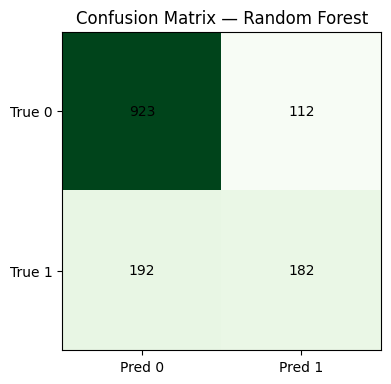

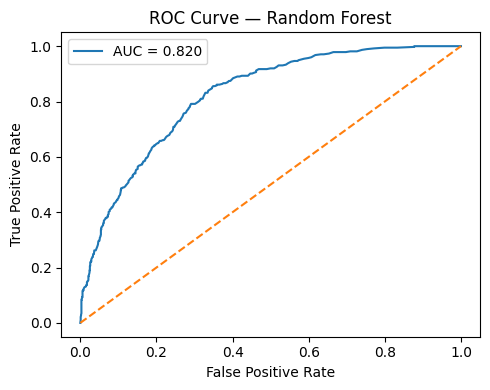

In [ ]:
#Rf
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve

# Predictions
y_pred_rf = rf.predict(X2_test)
y_proba_rf = rf.predict_proba(X2_test)[:, 1]

# Metrics
acc  = accuracy_score(y2_test, y_pred_rf)
prec = precision_score(y2_test, y_pred_rf, zero_division=0)
rec  = recall_score(y2_test, y_pred_rf)
f1   = f1_score(y2_test, y_pred_rf)
auc  = roc_auc_score(y2_test, y_proba_rf)

print("Random Forest Evaluation:")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"AUC-ROC  : {auc:.3f}\n")

print("Classification Report:")
print(classification_report(y2_test, y_pred_rf, digits=3))

# Confusion Matrix
cm = confusion_matrix(y2_test, y_pred_rf)
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap='Greens')
plt.title("Confusion Matrix — Random Forest")
plt.xticks([0,1], ['Pred 0','Pred 1'])
plt.yticks([0,1], ['True 0','True 1'])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y2_test, y_proba_rf)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()


**Explainable AI (XAI)**

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

X_shap = X2_test.copy()

feat_names = [str(c) for c in X_shap.columns]
dm = xgb.DMatrix(X_shap.values, feature_names=feat_names)

booster = xgb2.get_booster()

shap_contribs = booster.predict(dm, pred_contribs=True)
shap_values = shap_contribs[:, :-1]   # إزالة الـ bias

print("SHAP matrix shape:", shap_values.shape)


SHAP matrix shape: (1409, 20)


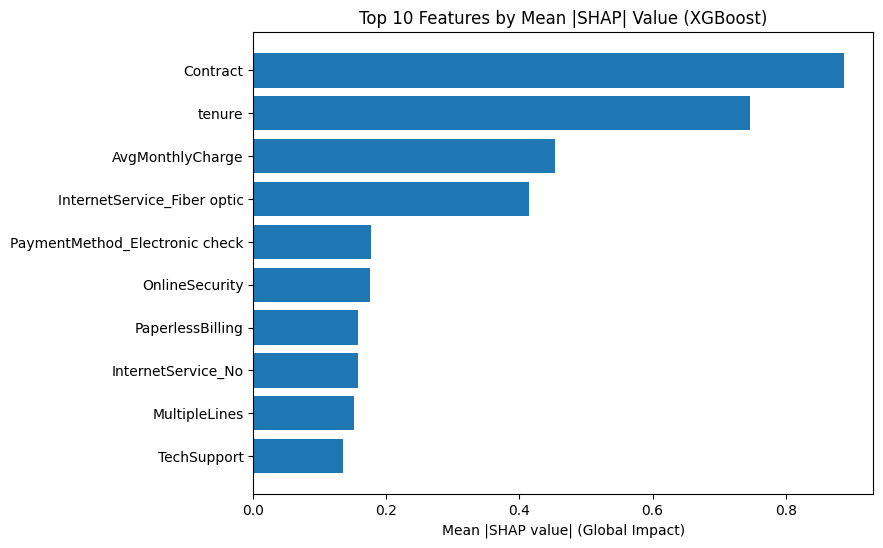

In [ ]:
mean_abs = np.abs(shap_values).mean(axis=0)
imp = pd.Series(mean_abs, index=feat_names).sort_values(ascending=False)

top = imp.head(10)
plt.figure(figsize=(8,6))
bars = plt.barh(top.index, top.values)
plt.title("Top 10 Features by Mean |SHAP| Value (XGBoost)")
plt.xlabel("Mean |SHAP value| (Global Impact)")
plt.gca().invert_yaxis()
plt.show()

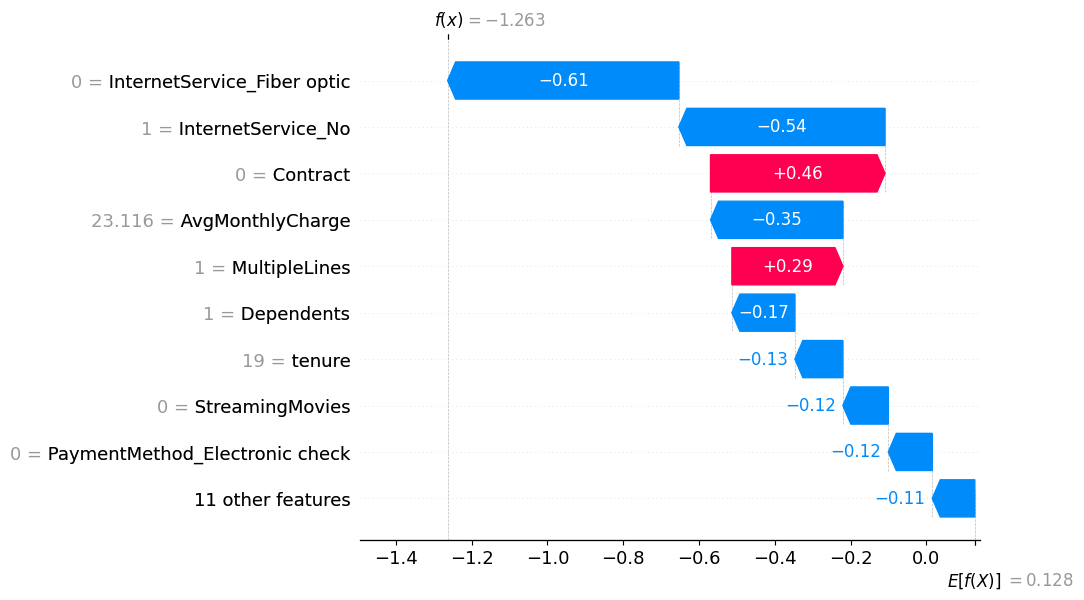

In [ ]:
sample_index = 7
sample = X2_test.iloc[[sample_index]].copy()

booster = xgb2.get_booster()
feat_names = booster.feature_names
sample = sample[feat_names]

dm_sample = xgb.DMatrix(sample.values, feature_names=feat_names)

shap_contribs_sample = booster.predict(dm_sample, pred_contribs=True)
shap_values_sample = shap_contribs_sample[0, :-1]
base_value = shap_contribs_sample[0, -1]

shap.initjs()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_sample,
        base_values=base_value,
        data=sample.iloc[0],
        feature_names=feat_names
    )
)


**Automated Smart Alerts (Real-Time Risk Detection)**

In [ ]:
THRESHOLD = 0.30

feat_names = xgb2.get_booster().feature_names

X_alert = df_final[feat_names].copy()

df_final["Churn_Prob"] = xgb2.predict_proba(X_alert)[:, 1]
df_final["Alert"] = np.where(df_final["Churn_Prob"] >= THRESHOLD, "High Risk", "Safe")

df_final.to_csv("customer_alerts_n.csv", index=False)

print(df_final["Alert"].value_counts(normalize=True) * 100)


Alert
Safe         51.015192
High Risk    48.984808
Name: proportion, dtype: float64


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_pred_new = (xgb2.predict_proba(X2_test)[:, 1] >= THRESHOLD).astype(int)

print("Precision:", precision_score(y2_test, y_pred_new, zero_division=0))
print("Recall:", recall_score(y2_test, y_pred_new))
print("F1:", f1_score(y2_test, y_pred_new))
print("\nConfusion Matrix:\n", confusion_matrix(y2_test, y_pred_new))


Precision: 0.4682080924855491
Recall: 0.8663101604278075
F1: 0.6078799249530957

Confusion Matrix:
 [[667 368]
 [ 50 324]]


In [ ]:
df_final.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,TechSupport,...,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlyCharge,IsNewCustomer,Churn_Prob,Alert
0,7590-VHVEG,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,29.850000,True,0.635567,High Risk
1,5575-GNVDE,0,0,0,34,1,0,1,0,0,...,0,0,0,0,0,1,55.573529,False,0.055390,Safe
2,3668-QPYBK,0,0,0,2,1,0,1,1,0,...,1,0,0,0,0,1,54.075000,True,0.418424,High Risk
3,7795-CFOCW,0,0,0,45,0,0,1,0,1,...,0,0,0,0,0,0,40.905556,False,0.056409,Safe
4,9237-HQITU,0,0,0,2,1,0,0,0,0,...,1,1,0,0,1,0,75.825000,True,0.604289,High Risk


**Recommendation Engine (Next Best Action System)**

In [ ]:
TH = 0.30
df_rec = df_final.copy()

def risk_level(p):
    if p >= 0.80:
        return "HIGH"
    elif p >= 0.60:
        return "MEDIUM"
    elif p >= TH:
        return "LOW"
    else:
        return "NO RISK"

df_rec["RiskLevel"] = df_rec["Churn_Prob"].apply(risk_level)

def next_best_action(row):
    p = row["Churn_Prob"]
    if p < TH:
        return "No action needed"

    contract = row.get("Contract", None)                    # 0/1/2
    fiber    = row.get("InternetService_Fiber optic", 0)    # 0/1
    echeck   = row.get("PaymentMethod_Electronic check", 0) # 0/1
    tech     = row.get("TechSupport", None)                 # 0/1
    avg      = row.get("AvgMonthlyCharge", None)            # رقم
    is_new   = row.get("IsNewCustomer", None)               # 0/1
    tenure   = row.get("tenure", None)


    if is_new is None and tenure is not None:
        is_new = int(tenure < 18)

    # 1) خطر عالي + عقد شهري
    if (p >= 0.60) and (contract == 0):
        return "Suggest upgrading to One-year or Two-year contract"

    # 2) Fiber + خطر عالي
    if (p >= 0.60) and (fiber == 1):
        return "Offer discounts or service-quality improvements"

    # 3) AvgMonthlyCharge عالي
    if (avg is not None) and (avg >= 80):
        return "Suggest lower-cost bundles or promotions"

    # 4) بدون TechSupport
    if (tech is not None) and (tech == 0):
        return "Recommend technical support package"

    # 5) Electronic check
    if echeck == 1:
        return "Encourage switching to Credit Card or Bank Transfer"

    # 6) New customer (<18)
    if is_new == 1:
        return "Provide welcome offers or personalized engagement"

    return "Send personalized offer / loyalty program benefits"

df_rec["Recommendation"] = df_rec.apply(next_best_action, axis=1)

# عرض
cols_to_show = ["customerID","Churn_Prob","RiskLevel","Recommendation",
                "Contract","InternetService_Fiber optic","PaymentMethod_Electronic check",
                "TechSupport","AvgMonthlyCharge","tenure","IsNewCustomer"]

rec_table = (df_rec[df_rec["Churn_Prob"] >= TH][cols_to_show]
             .sort_values("Churn_Prob", ascending=False))

display(rec_table.head(20))

df_rec.to_csv("next_best_action_recommendations.csv", index=False)
print(df_rec["Recommendation"].value_counts())


,customerID,Churn_Prob,RiskLevel,Recommendation,Contract,InternetService_Fiber optic,PaymentMethod_Electronic check,TechSupport,AvgMonthlyCharge,tenure,IsNewCustomer
2577,4910-GMJOT,0.991211,HIGH,Suggest upgrading to One-year or Two-year cont...,0,1,1,0,94.600000,1,True
4800,9300-AGZNL,0.991159,HIGH,Suggest upgrading to One-year or Two-year cont...,0,1,1,0,94.000000,1,True
6866,0295-PPHDO,0.990548,HIGH,Suggest upgrading to One-year or Two-year cont...,0,1,1,0,95.450000,1,True
3749,4424-TKOPW,0.990533,HIGH,Suggest upgrading to One-year or Two-year cont...,0,1,1,0,98.375000,2,True
1148,7851-WZEKY,0.989851,HIGH,Suggest upgrading to One-year or Two-year cont...,0,1,1,0,98.450000,2,True
1976,9497-QCMMS,0.989139,HIGH,Suggest upgrading to One-year or Two-year cont...,0,1,1,0,93.550000,1,True
3209,8149-RSOUN,0.988313,HIGH,Suggest upgrading to One-year or Two-year cont...,0,1,1,0,93.850000,1,True
3380,5178-LMXOP,0.988064,HIGH,Suggest upgrading to One-year or Two-year cont...,0,1,1,0,95.100000,1,True
2727,3387-VATUS,0.987188,HIGH,Suggest upgrading to One-year or Two-year cont...,0,1,0,0,92.560000,5,True
4585,1069-XAIEM,0.986634,HIGH,Suggest upgrading to One-year or Two-year cont...,0,1,1,0,85.050000,1,True


Recommendation
No action needed                                       3593
Suggest upgrading to One-year or Two-year contract     2102
Recommend technical support package                     593
Suggest lower-cost bundles or promotions                493
Offer discounts or service-quality improvements          95
Provide welcome offers or personalized engagement        75
Encourage switching to Credit Card or Bank Transfer      55
Send personalized offer / loyalty program benefits       37
Name: count, dtype: int64


In [ ]:
df_rec.to_csv("next_best_action_recommendations.csv", index=False)

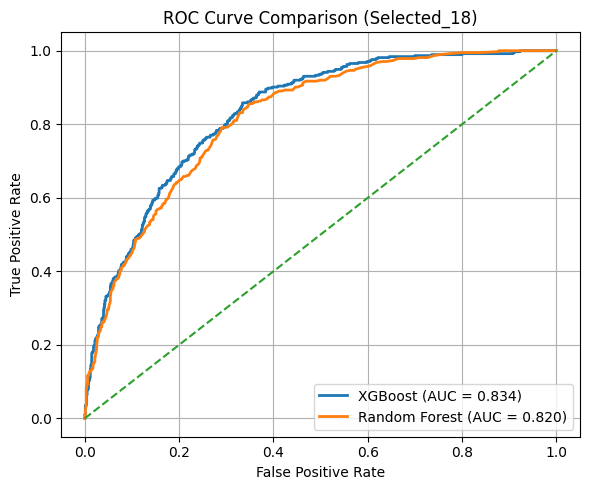

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ===== XGBoost =====
xgb_probs = xgb2.predict_proba(X2_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y2_test, xgb_probs)
auc_xgb = roc_auc_score(y2_test, xgb_probs)

# ===== Random Forest =====
rf_probs = rf.predict_proba(X2_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y2_test, rf_probs)
auc_rf = roc_auc_score(y2_test, rf_probs)

# ===== Plot =====
plt.figure(figsize=(6,5))

plt.plot(
    fpr_xgb, tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.3f})",
    linewidth=2
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})",
    linewidth=2
)

# Diagonal reference line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Selected_18)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
